# Quantum Optics - Homework 1

## Jan Chelmecki

The task is to display the eigenfunctions of

$$
H = −E_J \cos (\phi - \phi_{ext}) + 4 E_C (n-n_{ext})^2 + \frac{E_L}{2} \phi^2
$$

where $\phi$ and $n$ are conjugate variables henceforth associated to position and momentum, respectively (it is really a matter of language, and I like the good old $x$ and $p$ better).

The strategy will be the following.
1. Define the operators in the position space, since this is how we will want to represent the wavefunctions.
2. Discretize the space with a fine 1D grid - operators will then be finite matrices, making the problem numerically solvable.
3. For the potential, define a diagonal matrix.
4. Approximate the momentum operator $-i\hbar\partial_x$ with finite differences, and initialize the appropriate matrix.
5. Use the above to define the Hamiltionian and diagonalize it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

In [2]:
def solve(EJ,EC,EL,phi_ext,xmax,N):

    ### discretize space
    x = np.linspace(-xmax,xmax, N)
    dx = x[1]-x[0]

    #define the momentum operators
    p2 = np.zeros((N,N), complex)
    s = -1/(dx)**2
    for i in range(N):
        if i>0:
            p2[i,i-1] = s
        #endif
        p2[i,i] = -2*s
        if i<N-1:
            p2[i,i+1] = s
        #endif
    #end
    T = 4*EC*p2

    ### define the potential
    V_vals = -EJ*np.cos(x-phi_ext) +EL/2 * x**2
    V = np.diag(V_vals)

    H = Qobj(T+V)
    energies, eigenstates = H.eigenstates()

    states=[]
    for n in range(4):
        psi = eigenstates[n].full().flatten()
        psi = psi / np.sqrt(np.sum(np.abs(psi)**2) * dx)  # normalize
        states.append(psi)
    return energies[:4:], states
#end

In [3]:
def show_states(EJ,EC,EL,phi_ext,xmax,N):
    x = np.linspace(-xmax,xmax, N)
    V = -EJ*np.cos(x-phi_ext) +EL/2 * x**2

    energies, states = solve(EJ,EC,EL,phi_ext,xmax,N)
    print("Energies = ", energies)
    plt.plot(x, V)
    for i in range(len(energies)):
        plt.plot(x,energies[i]+np.real(states[i]), label="|"+str(i)+">")
    plt.grid()
    plt.xlabel("$\phi$")
    plt.ylabel("$E/\hbar$ (GHZ)")
    xlim = np.abs(x[np.argmax(V)])
    plt.xlim(-xlim,xlim)
    plt.ylim(np.min(V)-0.2, V[int(N/2)]+1.0)
    plt.legend()
#end

Energies =  [-2.32642161 -2.32461348  1.38182271  1.43547638]


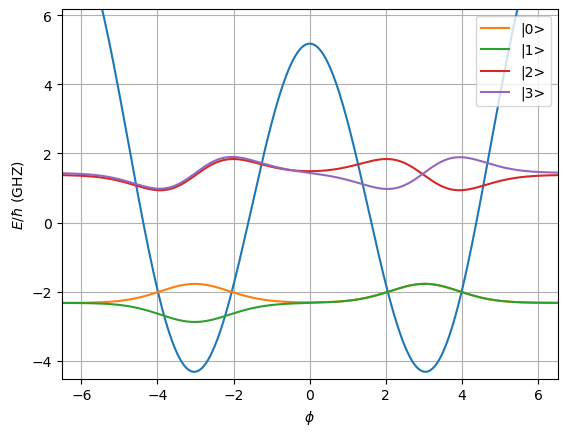

In [4]:
EJ = 5.178 #GHz*h
EC = 0.4144 #GHz*h
EL = 0.18 #GHz*h
phi_ext = np.pi*1.00
n_ext = 0.0

xmax = 10.0
N = 500

show_states(EJ,EC,EL,phi_ext,xmax,N)

Levels $\ket{0}$ and $\ket{1}$ as well as $\ket{2}$ and $\ket{3}$ are almost degenerate and indeed, they would be for an infite well. Here the degeneracy is lifted due to tunneling. In each pair, the symmetric eigenstates has slightly lower energy.

Now, let's plot transition energies, since it is the most experimentally relevant characteristic of the system.

Text(0, 0.5, 'Drive frequency (GHz)')

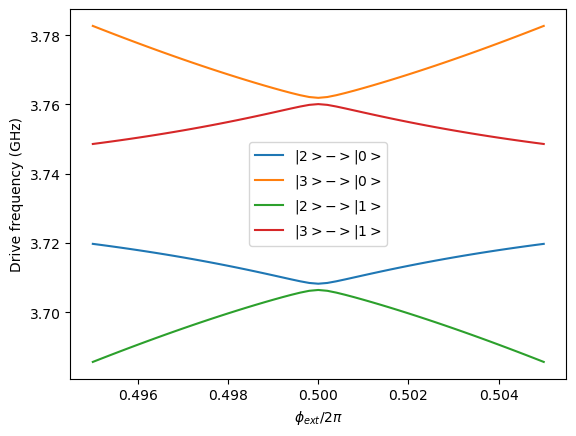

In [5]:
points = 51
phi_ext_list = np.linspace(0.99*np.pi,1.01*np.pi,points)
E_arr = np.zeros((4,points))

for i in range(points):
    EJ = 5.178 #GHz*h
    EC = 0.4144 #GHz*h
    EL = 0.18 #GHz*h
    phi_ext = phi_ext_list[i]
    E, states = solve(EJ,EC,EL,phi_ext,xmax,N)
    E_arr[:,i] = E

plt.plot(phi_ext_list/(2*np.pi),E_arr[2,:]-E_arr[0,:],label="$|2>  ->  |0>$")
plt.plot(phi_ext_list/(2*np.pi),E_arr[3,:]-E_arr[0,:],label="$|3>  ->  |0>$")
plt.plot(phi_ext_list/(2*np.pi),E_arr[2,:]-E_arr[1,:],label="$|2>  ->  |1>$")
plt.plot(phi_ext_list/(2*np.pi),E_arr[3,:]-E_arr[1,:],label="$|3>  ->  |1>$")
plt.legend()
plt.xlabel("$\phi_{ext}/2\pi$")
plt.ylabel("Drive frequency (GHz)")

The interesting part is when the curves almost cross - this is where tunneling comes in to lift the degeneracy.

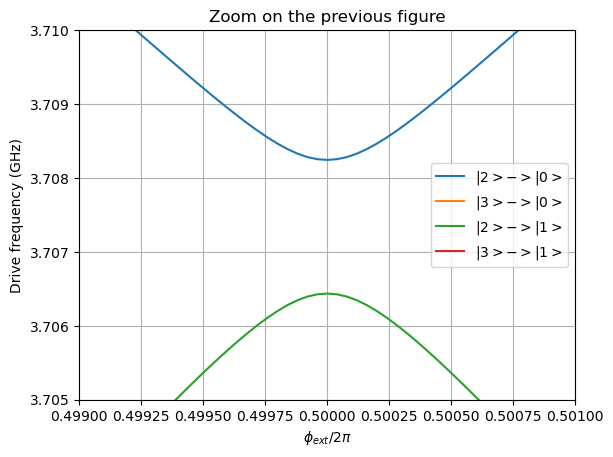

In [6]:
points = 51
phi_ext_list = np.linspace(2*0.499*np.pi,2*0.501*np.pi,points)
E_arr = np.zeros((4,points))

for i in range(points):
    EJ = 5.178 #GHz*h
    EC = 0.4144 #GHz*h
    EL = 0.18 #GHz*h
    phi_ext = phi_ext_list[i]
    E, states = solve(EJ,EC,EL,phi_ext,xmax,N)
    E_arr[:,i] = E

plt.plot(phi_ext_list/(2*np.pi),E_arr[2,:]-E_arr[0,:],label="$|2>  ->  |0>$")
plt.plot(phi_ext_list/(2*np.pi),E_arr[3,:]-E_arr[0,:],label="$|3>  ->  |0>$")
plt.plot(phi_ext_list/(2*np.pi),E_arr[2,:]-E_arr[1,:],label="$|2>  ->  |1>$")
plt.plot(phi_ext_list/(2*np.pi),E_arr[3,:]-E_arr[1,:],label="$|3>  ->  |1>$")
plt.legend()
plt.xlabel("$\phi_{ext}/2\pi$")
plt.ylabel("Drive frequency (GHz)")
plt.xlim(0.499,0.501)
plt.ylim(3.705,3.710)
plt.title("Zoom on the previous figure")
plt.grid()